# Four neutrinos, and a sterile state

Everything so far has been two or three flavors. `oscprob4nu` carries the same closed-form treatment to **four**, through the SU(4) algebra — and four is where the road ends, for a reason worth knowing.

The payoff is 3+1 sterile scenarios. A 3+1 system is often called "leaky", because probability drains out of the three active flavors; but that is a statement about the $3\times3$ block, not about the physics. Over all four states the evolution is closed and unitary, which is exactly what the method assumes.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
# A 3+1 scenario: the NuFit best fit for the active sector,
# plus an eV-scale sterile with sin^2(th14) = sin^2(th24) = 0.1
DM41 = 1.0                       # [eV^2]
S14 = S24 = np.sqrt(0.10)
S34 = 0.0

H_VAC_4NU = hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF,
    S14, S24, S34,
    gd.DCP_NO_BF, gd.D21_NO_BF, gd.D31_NO_BF, DM41)

print("H_vac shape:", H_VAC_4NU.shape)

H_vac shape: (4, 4)


## One four-flavor probability

Sixteen probabilities come back, with the *initial* flavor varying slowest — the same ordering as at three flavors. The fourth state is the sterile one.

In [3]:
energy = 1.0*GEV
baseline = 1300.0*KM

H = hamiltonians4nu.hamiltonian_4nu_matter(
    H_VAC_4NU, energy, gd.VCC_EARTH_CRUST, gd.VNC_EARTH_CRUST)
prob = np.array(oscprob4nu.probabilities_4nu(H, baseline))

flavors = ["e", "mu", "tau", "s"]
table = prob.reshape(4, 4)
print("P(alpha -> beta), rows = initial flavor\n")
print("%-8s" % "" + "".join("%10s" % ("-> " + f) for f in flavors))
for i, a in enumerate(flavors):
    print("%-8s" % ("nu_" + a)
          + "".join("%10.5f" % v for v in table[i]))
print("\nrows sum to:", np.round(table.sum(axis=1), 12))

P(alpha -> beta), rows = initial flavor

              -> e     -> mu    -> tau      -> s
nu_e       0.83780   0.00259   0.04425   0.11537
nu_mu      0.02343   0.38769   0.56169   0.02719
nu_tau     0.02250   0.57735   0.35918   0.04097
nu_s       0.11627   0.03237   0.03488   0.81647

rows sum to: [1. 1. 1. 1.]


## The matter potential has a sterile entry

This is the four-flavor trap, and it is the analogue of getting antineutrinos wrong: it is **invisible in vacuum** and it moves the resonance.

Active neutrinos feel the charged-current potential $V_{CC}$ (the electron flavor) and the flavor-universal neutral-current potential $V_{NC}$ (all three). A sterile state feels neither. Since a term proportional to the identity is only a global phase, subtracting $V_{NC}\mathbb{1}$ from all four costs nothing and leaves

$$A_4 = \mathrm{diag}(V_{CC},\, 0,\, 0,\, -V_{NC})$$

so the sterile entry is *not* zero.

In [4]:
added = H - H_VAC_4NU/energy
print("diagonal of the matter term [eV]:")
for f, v in zip(flavors, np.diag(added).real):
    print("  nu_%-4s %+.6e" % (f, v))
print("\n-V_NC / V_CC = %.4f"
      % (-gd.VNC_EARTH_CRUST/gd.VCC_EARTH_CRUST))

diagonal of the matter term [eV]:
  nu_e    +1.135817e-13
  nu_mu   +0.000000e+00
  nu_tau  +0.000000e+00
  nu_s    +5.679086e-14

-V_NC / V_CC = 0.5000


## Sterile oscillations against energy

An eV-scale splitting oscillates *fast*: the phase goes as $\Delta m^2_{41} L / 4E$, so at a long-baseline energy and distance it has already averaged out and only its mean survives. That is precisely why short-baseline experiments are the probe — at $L/E \sim 1$ km/GeV the oscillation is resolved rather than averaged.

So this is a short baseline, 600 m, which is where the structure actually lives.

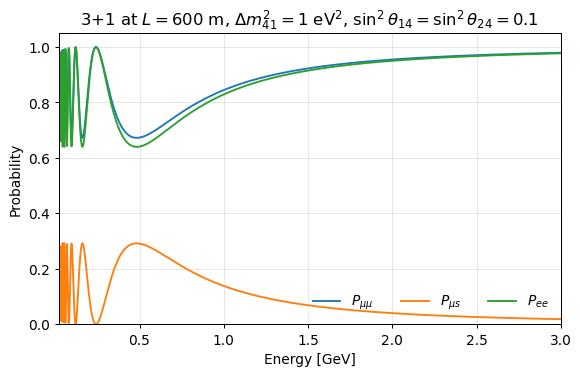

In [5]:
L_sbl = 0.6*KM                      # 600 m
E_gev = np.linspace(0.02, 3.0, 1500)

H_stack = hamiltonians4nu.hamiltonian_4nu_matter(
    H_VAC_4NU, E_gev*GEV, gd.VCC_EARTH_CRUST,
    gd.VNC_EARTH_CRUST)
p = oscprob4nu.probabilities_4nu(H_stack, L_sbl)

fig, ax = plt.subplots()
ax.plot(E_gev, p[:, 5], label=r"$P_{\mu\mu}$")
ax.plot(E_gev, p[:, 7], label=r"$P_{\mu s}$")
ax.plot(E_gev, p[:, 0], label=r"$P_{ee}$")
ax.set_xlim(E_gev[0], E_gev[-1])
ax.set_ylim(0.0, 1.05)
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel("Probability")
ax.set_title(r"3+1 at $L = 600$ m, "
             r"$\Delta m^2_{41} = 1$ eV$^2$, "
             r"$\sin^2\theta_{14} = \sin^2\theta_{24} = 0.1$")
ax.legend(ncol=3, loc="lower right")
plt.show()

The active flavors are barely oscillating at 600 m through the standard splittings — those need hundreds of kilometres — so everything visible here is the sterile state, and $P_{\mu\mu}$ and $P_{ee}$ dip exactly where $P_{\mu s}$ rises. At $L = 1300$ km the same curves would be a solid averaged band, which is the point: the two regimes probe different things.

## The sterile matter resonance through the Earth

The reason four flavors is worth having in a code like this. An eV-scale sterile driven through Earth matter develops a resonance in the TeV range for antineutrinos — the signature IceCube searches for. Here it is as a map in energy and zenith angle, built the same way as the three-flavor oscillogram: broadcast the two axes and let one call fill the grid.

This uses a single average mantle density, which is what makes the grid one broadcast call. `earth.probabilities_4nu_earth` does the full PREM profile instead, slab by slab, one zenith angle at a time; the cell after this one checks the two against each other.

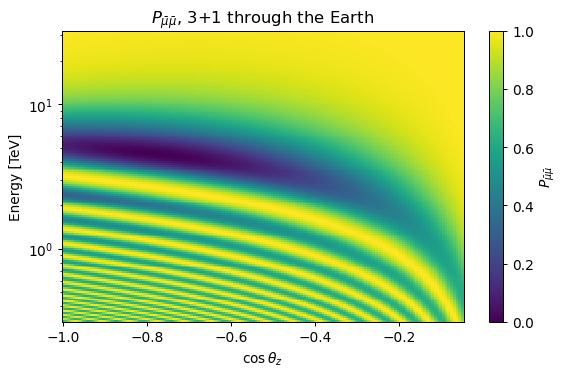

In [6]:
import earth

n_e, n_c = 150, 150
E_tev = np.logspace(-0.5, 1.5, n_e)          # 0.3 - 30 TeV
costhz = np.linspace(-1.0, -0.05, n_c)

# Antineutrinos: conjugate the vacuum term and flip both
# potentials.  One average mantle density here, so that the
# whole grid is a single broadcast call.
rho_mantle = 4.5                              # [g cm^-3]
vcc = earth.matter_potential(rho_mantle)
H_bar = hamiltonians4nu.hamiltonian_4nu_matter(
    np.conj(H_VAC_4NU), E_tev[:, None]*1.0e3*GEV,
    -vcc, -gd.VNC_EARTH_CRUST*rho_mantle/3.0)

# Path length through the Earth at each zenith angle
L_grid = np.array([earth.distance_traveled_inside_earth(c)
                   for c in costhz])*KM

grid = oscprob4nu.probabilities_4nu(H_bar, L_grid[None, :])
p_mumu = grid[:, :, 5]

fig, ax = plt.subplots()
mesh = ax.pcolormesh(costhz, E_tev, p_mumu,
                     shading="auto", cmap="viridis",
                     vmin=0.0, vmax=1.0)
ax.set_yscale("log")
ax.set_xlabel(r"$\cos\theta_z$")
ax.set_ylabel("Energy [TeV]")
ax.set_title(r"$P_{\bar\mu\bar\mu}$, 3+1 through the Earth")
ax.grid(False)
fig.colorbar(mesh, ax=ax, label=r"$P_{\bar\mu\bar\mu}$")
plt.show()

### What the averaging costs

The map above uses one average mantle density, which is what makes the whole grid a single broadcast call. `earth.probabilities_4nu_earth` instead cuts the chord at every PREM shell boundary, takes the density at the midpoint of each sub-slab, and multiplies the per-slab operators — the four-flavor case of the machinery notebooks 06 and 07 use at three.

The comparison below is for **neutrinos**, not the antineutrinos of the map: `probabilities_4nu_earth` takes the potentials with the sign they have for neutrinos, exactly as its three-flavor sibling does. Each row uses the path-weighted mean PREM density along that very chord, so the only difference left is the averaging itself.

In [7]:
print("costhz   rho_mean   averaged      PREM   difference")
for c in (-0.2, -0.5, -0.8, -0.95, -1.0):
    L = earth.distance_traveled_inside_earth(c)*KM
    w, d = earth.earth_slabs(c, 8)
    rho = float(np.sum(w*d)/np.sum(w))
    H_avg = hamiltonians4nu.hamiltonian_4nu_matter(
        H_VAC_4NU, 3.0e3*GEV,
        earth.matter_potential(rho),
        earth.matter_potential_nc(rho))
    averaged = oscprob4nu.probabilities_4nu(H_avg, L)[5]
    prem = earth.probabilities_4nu_earth(H_VAC_4NU, 3.0e3*GEV, c)[5]
    print("%6.2f   %7.2f   %8.4f  %8.4f   %+9.4f"
          % (c, rho, averaged, prem, prem-averaged))

costhz   rho_mean   averaged      PREM   difference
 -0.20      3.29     0.8255    0.8273     +0.0019
 -0.50      4.00     0.9062    0.8875     -0.0187
 -0.80      4.80     0.9508    0.9213     -0.0295
 -0.95      7.72     0.9231    0.7989     -0.1242
 -1.00      8.59     0.9523    0.9970     +0.0447


Through the mantle the two agree to a few parts in a hundred, which is the level at which replacing a varying density by its mean is defensible. The chord that grazes the core is several times worse than any of them: a single number cannot stand in for a profile that jumps by a factor of two at the core-mantle boundary, however well chosen the number is. Note that the diametric chord is *not* the worst case here — it is symmetric and spends most of its length in the core, so its mean is closer to representative than the grazing one's. That is the kind of thing `earth` exists to get right without being guessed at.

The dark band is the sterile matter resonance: a region of energy and zenith angle where muon antineutrinos are strongly depleted into the sterile state. Its position depends on $\Delta m^2_{41}$, which is what makes it a search channel.

## Sterile states and new interactions together

3+1 does not have to be the only new physics in the problem. `hamiltonians4nu.hamiltonian_4nu_nsi` adds non-standard interactions on top of the sterile state, and the flavor structure is the physically interesting part: NSI are a modification of a *standard-model* interaction, and a sterile state has none — so the $\epsilon$ matrix acts on the active block only, and the sterile row and column stay untouched.

The sterile entry keeps the $-V_{NC}$ it had before, since that came from removing the neutral-current potential of the active states, not from any interaction of the sterile one.

In [8]:
H_nsi = hamiltonians4nu.hamiltonian_4nu_nsi(
    H_VAC_4NU, energy, gd.VCC_EARTH_CRUST,
    gd.VNC_EARTH_CRUST, gd.EPS_3)

# What the NSI term added, on top of standard matter
added = np.array(H_nsi) - np.array(H)
print("NSI contribution [eV], real part:")
print("%8s" % "" + "".join("%12s" % f for f in flavors))
for i, a in enumerate(flavors):
    print("%8s" % a
          + "".join("%12.3e" % added[i, j].real
                     for j in range(4)))

print("\nsterile row and column untouched : %s"
      % bool(np.all(np.abs(added[3, :]) == 0.0)
             and np.all(np.abs(added[:, 3]) == 0.0)))

NSI contribution [eV], real part:
                   e          mu         tau           s
       e   6.815e-15  -6.815e-15   0.000e+00   0.000e+00
      mu  -6.815e-15   1.363e-13   0.000e+00   0.000e+00
     tau   0.000e+00   0.000e+00   0.000e+00   0.000e+00
       s   0.000e+00   0.000e+00   0.000e+00   0.000e+00

sterile row and column untouched : True


In [9]:
p_nsi = np.array(oscprob4nu.probabilities_4nu(
    H_nsi, baseline)).reshape(4, 4)
p_std = np.array(oscprob4nu.probabilities_4nu(
    H, baseline)).reshape(4, 4)

print("%-10s %12s %12s %12s"
      % ("channel", "3+1", "3+1 with NSI", "change"))
for i, a in enumerate(flavors):
    for j, b in enumerate(flavors):
        if i == j or (i, j) not in ((0, 1), (1, 0), (1, 3)):
            continue
        print("P(%s->%s)%s %12.6f %12.6f %+12.6f"
              % (a, b, " "*(3-len(a)-len(b)),
                 p_std[i, j], p_nsi[i, j],
                 p_nsi[i, j]-p_std[i, j]))

channel             3+1 3+1 with NSI       change
P(e->mu)     0.002585     0.000743    -0.001843
P(mu->e)     0.023427     0.027737    +0.004310
P(mu->s)     0.027187     0.008088    -0.019099


The sterile channel $P(\nu_\mu \to \nu_s)$ moves too, even though the sterile state feels no NSI directly — because NSI reshape the active block, and the active and sterile states are mixed. Nothing in this calculation is a special case: it is still one Hermitian matrix handed to the same routine.

## What is actually new at four flavors

Three things, and each follows from SU(4) having rank three where SU(3) has rank two.

In [10]:
I2, I3, I4 = oscprob4nu.su4_invariants(H)
print("three invariants, not two:")
print("  I2 = %+.6e" % I2)
print("  I3 = %+.6e" % I3)
print("  I4 = %+.6e" % I4)

psi = oscprob4nu.psi_roots_4nu(I2, I3, I4)
print("\nthe characteristic equation is a quartic; its roots:")
print(" ", np.array(psi))
print("  vs numpy.linalg.eigvalsh:")
H_traceless = H - np.trace(H).real/4.0*np.eye(4)
print(" ", np.sort(np.linalg.eigvalsh(H_traceless)))

three invariants, not two:
  I2 = +9.359549e-20
  I3 = +2.337923e-29
  I4 = +5.840018e-39

the characteristic equation is a quartic; its roots:
  [-1.25344227e-10 -1.25245525e-10 -1.24100152e-10  3.74689904e-10]
  vs numpy.linalg.eigvalsh:
  [-1.25344227e-10 -1.25245525e-10 -1.24100152e-10  3.74689904e-10]


And the star-product tower grows a rung. At three flavors $(h \star h) \star h = \frac{1}{3}|h|^2 h$, which is what lets `oscprob3nu` stop after two terms. That identity is a Cayley–Hamilton accident of $n = 3$ and is simply **false** at $n = 4$:

In [11]:
lam = oscprob4nu.LAMBDA_SU4
rng = np.random.default_rng(7)
h = rng.standard_normal(15)
Ht = np.einsum("a,aij->ij", h, lam)
i2, _, _ = oscprob4nu.su4_invariants(Ht)
tower = (0.5*np.einsum("aij,ji->a", lam, Ht @ Ht @ Ht).real
         - 0.5*i2*h)
deviation = (np.max(np.abs(tower - i2*h/3.0))
             / np.max(np.abs(tower)))
print("relative deviation from the SU(3) identity: %.0f%%"
      % (100*deviation))
print("-> ((h*h)*h)_a is independent data at n = 4")

relative deviation from the SU(3) identity: 87%
-> ((h*h)*h)_a is independent data at n = 4


## Accuracy, honestly

Before the numbers: **none of this is near a measurable effect.** Oscillation probabilities meet data at the per-cent level, and both figures below sit several orders of magnitude beneath anything an experiment resolves. What follows matters for the library's claim to be *exact*, for error accumulating when `slabs` and `earth` multiply operators across many layers, and for keeping the regression suite tight enough to catch a real mistake — not for whether these probabilities are good enough to use.

With that said: for a generic Hamiltonian the four-flavor expansion is exact to round-off, like its two- and three-flavor siblings. A **stiff** spectrum is different, and 3+1 with an eV-scale sterile is stiff — the eigenvalues span four orders of magnitude with three of them clustered, and forming the three invariants in double precision compresses the $4\times4$ matrix into three numbers and loses what separates the cluster. That is ordinary ill-conditioning of polynomial roots against their coefficients, so no better root-finder helps.

The library refines the roots against the *matrix* instead — one Newton step on $\chi(\psi) = \det(\psi\mathbb{1} - \tilde H)$, which reads the Hamiltonian entries at full precision. `POLISH_ROOTS` controls it, and here is what it buys:

In [12]:
def reference(Hs, L):
    Ht = Hs - np.einsum("...ii->...", Hs).real[..., None, None]/4.0*np.eye(4)
    w, V = np.linalg.eigh(Ht)
    U = np.einsum("...ik,...k,...jk->...ij", V,
                  np.exp(-1j*w*L), V.conj())
    return np.abs(np.swapaxes(U, -1, -2))**2


P_ref = reference(H_stack, baseline).reshape(-1, 16)
for flag in (True, False):
    oscprob4nu.POLISH_ROOTS = flag
    P = oscprob4nu.probabilities_4nu(H_stack, baseline)
    print("POLISH_ROOTS = %-5s : max |P - P_eigh| = %.2e"
          % (flag, np.max(np.abs(P - P_ref))))
oscprob4nu.POLISH_ROOTS = True

POLISH_ROOTS = True  : max |P - P_eigh| = 4.12e-09
POLISH_ROOTS = False : max |P - P_eigh| = 9.86e-06


Three alternatives were measured against `mpmath` at fifty decimal digits before settling on this one, and two of them lose in instructive ways.

| Strategy for the roots | Relative error | Cost, 200k points | Closed form? |
|---|---|---|---|
| Closed form alone | 8.3e-11 | 0.17 s | yes |
| **Closed form + one Newton step** | **1.1e-16** | 0.41 s | yes |
| `numpy.linalg.eigvalsh` | 7.4e-16 | 0.17 s | no |
| Closed form in `numpy.longdouble` | 4.5e-11 | 0.43 s | yes |

The Newton step is about **seven times more accurate than LAPACK**, because `eigvalsh` reduces the matrix by similarity transforms that each carry a backward error $\sim\epsilon\|H\|$, while this converges onto the root of $\det(\psi\mathbb{1} - \tilde H)$ for the matrix it was handed.

Extended precision buys under one digit rather than the three its extra mantissa suggests — the cluster amplifies coefficient error — and is slower, since `float128` is not hardware-vectorised. It is also silently `float64` on Apple Silicon and Windows, so it would appear to work while doing nothing.

## A decoupled sterile state reproduces three flavors

The strongest check available, and the one worth running if you ever doubt a four-flavor number: switch the three sterile angles off and the active block must be exactly what `oscprob3nu` gives — a different module, written against a different algebra.

In [13]:
H_decoupled = hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, 0.0, 0.0, 0.0,
    gd.DCP_NO_BF, gd.D21_NO_BF, gd.D31_NO_BF, DM41)

four = np.array(oscprob4nu.probabilities_4nu(
    H_decoupled/energy, baseline)).reshape(4, 4)
three = np.array(oscprob3nu.probabilities_3nu(
    np.asarray(H_VAC_3NU)/energy, baseline)).reshape(3, 3)

print("max |4nu active block - 3nu| = %.2e"
      % np.max(np.abs(four[:3, :3] - three)))
print("leakage into the sterile state = %.2e"
      % np.max(np.abs(four[:3, 3])))

max |4nu active block - 3nu| = 3.03e-14
leakage into the sterile state = 0.00e+00


## Why it stops at four

Not for want of trying. The whole construction rests on writing the eigenvalues of the traceless Hamiltonian in closed form — that is, solving its characteristic polynomial **in radicals**. That polynomial has degree $n$.

Quadratics, cubics and quartics are solvable in radicals. The general quintic is not: that is the Abel–Ruffini theorem, and Galois theory says why — $S_5$ is not a soluble group, while $S_2$, $S_3$ and $S_4$ are. At $n = 5$ there is simply no formula to write down, and the shortfall is a theorem rather than a gap in anyone's algebra.

What does *not* stop is the philosophy. Nothing above the eigenvalues needs radicals — the interpolation over the roots, the fact that eigenvectors are never required, the probability construction — so feeding numerically computed eigenvalues into the same machinery degrades gracefully at any $n$. It would just no longer be a closed form, which is this library's reason to exist.

So four flavors is both the natural stopping point and a useful one: it is exactly what 3+1 needs.

---

**Previous:** [Numerical edge cases](15_numerical_edge_cases.ipynb)  
**Next:** [Cross-checks with other codes](17_cross_checks.ipynb) --- corroboration from nuSQuIDS and Zaglauer-Schwarzer  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)